In [2]:
import sys
import os
import argparse
import re
import pandas as pd
from collections import defaultdict
from Bio import SearchIO
from Bio import SeqIO
import matplotlib.pyplot as plt
import math
from adjustText import adjust_text
import numpy as np
from tslearn.metrics import dtw
import random

In [3]:
# make_dir(path)
#
def make_dir(path):
    if not os.path.exists(path):
        os.mkdir(path)
        
lin_hits_table = "/p/vast1/ibap/chivian1/proj/viral_fams/tables/RVDB_FAMs_v29.0/RVDB_FAMs_v29.0-lineage_hits_and_host_range_cats-coverage_0.50.tsv"
lin_thresh_table = "/p/vast1/ibap/chivian1/proj/viral_fams/tables/RVDB_FAMs_v29.0/RVDB_FAMs_v29.0-lineage_marker_fams_with_thresholds-coverage_0.50.tsv"
db_name = "RVDB_FAMs_v29.0"
outdir = "/p/lustre1/golez1/RVDB_ICTV_ref_seqs"

# lin_hits_table = "/p/vast1/ibap/chivian1/proj/viral_fams/tables/VOGDB_vfam_r225/VOGDB_vfam_r225-lineage_hits_and_host_range_cats-coverage_0.50.tsv"
# lin_thresh_table = "/p/vast1/ibap/chivian1/proj/viral_fams/tables/VOGDB_vfam_r225/VOGDB_vfam_r225-lineage_marker_fams_with_thresholds-coverage_0.50.tsv"
# db_name = "VOGDB_vfam"
# outdir = "/p/lustre1/golez1/VOGDB_vfam_ICTV_ref_seqs"

# lin_hits_table = "/p/vast1/ibap/chivian1/proj/viral_fams/tables/VOGDB_vogs_r225/VOGDB_vogs_r225-lineage_hits_and_host_range_cats-coverage_0.50.tsv"
# lin_thresh_table = "/p/vast1/ibap/chivian1/proj/viral_fams/tables/VOGDB_vogs_r225/VOGDB_vogs_r225-lineage_marker_fams_with_thresholds-coverage_0.50.tsv"
# db_name = "VOGDB_vog"
# outdir = "/p/lustre1/golez1/VOGDB_vog_ICTV_ref_seqs"

hmm_hits_dir = "/p/vast1/ibap/chivian1/proj/viral_fams/annot"
genomes_dir = "/p/vast1/ibap/chivian1/proj/viral_fams/data/refseq_20240730/ICTV_exemplars/genomes"

make_dir(outdir)

In [4]:
# read_lin_hits_to_dict(filepath)
#
def read_lin_hits_to_dict(filepath):
    prot_fam_map = defaultdict(lambda: defaultdict(list))
    df = pd.read_csv(filepath, sep="\t", index_col=0)
    genome_hits_map = {fam: row["GENOME_HITS"] for fam, row in df.iterrows()}

    for fam, genomes in genome_hits_map.items():
        genomes = genomes.split(";")
        for genome in genomes:
            accession_info = genome.split(":")
            genome_id = accession_info[0]
            prot_id = accession_info[1]
            prot_fam_map[genome_id][prot_id].append(fam)

    return prot_fam_map

# get fam prot hits
# genome -> protein -> fams_list
prot_fam_map = read_lin_hits_to_dict(lin_hits_table)

In [5]:
# read_lin_thresh_to_dict(filepath)
#
def read_lin_thresh_to_dict(filepath):
    df = pd.read_csv(filepath, sep="\t", usecols=[0, 1], index_col=0)
    
    highest_thresh_df = df.loc[df.groupby(df.index)['BITSCORE_THRESH'].idxmax()]
    lowest_thresh_df = df.loc[df.groupby(df.index)['BITSCORE_THRESH'].idxmin()]

    return {fam: info["BITSCORE_THRESH"] for fam, info in highest_thresh_df.iterrows()}, {fam: info["BITSCORE_THRESH"] for fam, info in lowest_thresh_df.iterrows()}

fam_highest_thresh_map, fam_lowest_thresh_map = read_lin_thresh_to_dict(lin_thresh_table)

In [6]:

# get_hit_coords(hmm_hits_dir, db_name, prot_fam_map)
#
def get_hit_coords(hmm_hits_dir, db_name, prot_fam_map):
    prot_coords = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    prot_bitscores = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for annot_root, annot_dirs, annot_files in os.walk(hmm_hits_dir):
        for genome in annot_dirs:
            if genome in prot_fam_map.keys():
                for genome_root, genome_dirs, genome_files in os.walk(os.path.join(annot_root, genome)):
                    for file in genome_files:
                        if db_name in file and "domtbl" in file:
                            with open(os.path.join(genome_root, file), 'r') as file:
                                for qresult in SearchIO.parse(file, 'hmmscan3-domtab'):
                                    for hit in qresult.hits:
                                        for hsp in hit.hsps:
                                            query = qresult.id
                                            target = hit.id
                                            bitscore = hsp.bitscore
                                            env_start = hsp.env_start
                                            env_end = hsp.env_end
                                            if query in prot_fam_map[genome].keys():
                                                if target in prot_fam_map[genome][query]:
                                                    prot_coords[genome][query][target].append((env_start, env_end))
                                                    prot_bitscores[genome][query][target].append(bitscore)
    
    return prot_coords, prot_bitscores

# get hit coords
# genome -> protein -> fam: [(start1, end1), ...], genome -> protein -> fam: [bitscore1, ...]
prot_fam_coords, prot_bitscores = get_hit_coords(hmm_hits_dir, db_name, prot_fam_map)

In [7]:
# extract_name(attributes_string)
#
def extract_name(attributes_string):
    attributes = attributes_string.split(";")
    for attribute in attributes:
        if attribute.startswith("Name="):
            return attribute.split("=")[1]

# read_fasta_to_dict(filepath)
#
def read_fasta_to_dict(filepath):
    seq_map = dict()
    with open(filepath, "r") as file:
        lines = file.readlines()
        name = ""
        seq = ""
        for line in lines:
            line = line.strip("*\n")
            if line.startswith(">"):
                if name and seq:
                    seq_map[name] = seq
                name = line.split(" ")[0][1:]
                seq = ""
            else:
                seq += line
                
        if name and seq:
            seq_map[name] = seq
    
    return seq_map
        
# get_genome_info(genomes_dir, prot_fam_coords)
#
def get_genome_info(genomes_dir, prot_fam_coords):
    fam_seq_map = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    seq_map = defaultdict(dict)
    tax_map = dict()
    gene_pos_map = defaultdict(lambda: defaultdict(list))
    full_genome_region = dict()
    
    for genome_root, genome_dirs, genome_files in os.walk(genomes_dir):
        for genome in genome_dirs:
            for info_root, info_dirs, info_files in os.walk(os.path.join(genome_root, genome)):
                if any([file.endswith("-protein.faa") for file in info_files]):
                    for file in info_files:
                        filepath = os.path.join(info_root, file)
                        
                        if file.endswith("-protein.faa"):
                            fasta_dict = read_fasta_to_dict(filepath)
                            for prot, seq in fasta_dict.items():
                                seq_map[genome][prot] = seq
                                if prot in prot_fam_coords[genome].keys():
                                    for fam, all_coords in prot_fam_coords[genome][prot].items():
                                        for coords in all_coords:
                                            fam_seq_map[fam][genome][prot] = seq[coords[0]:coords[1]]

                        elif file.endswith("-genomic.gbff"):
                            for record in SeqIO.parse(filepath, "genbank"):
                                taxonomy = "; ".join(record.annotations["taxonomy"]) + f"; {record.annotations["organism"]}"
                                if "Henifovirus" in taxonomy:
                                    print(genome)
                                tax_map[genome] = taxonomy

                        elif file.endswith("-genomic.gff"):
                            with open(filepath) as gff_file:
                                lines = gff_file.readlines()
                                for line in lines:
                                    if not line.startswith("#"):
                                        line = line.strip()
                                        features = line.split("\t")

                                        if features[2] == "CDS":
                                            start = int(features[3]) - 1
                                            stop = int(features[4])
                                            strand = features[6]
                                            prot = extract_name(features[8])

                                            if strand == "+":
                                                gene_pos_map[genome][prot].append((start, stop))
                                            elif strand == "-":
                                                gene_pos_map[genome][prot].append((stop, start))

                                        elif features[2] == "region":
                                            start = int(features[3]) - 1
                                            stop = int(features[4])
                                            full_genome_region[genome] = (start, stop)

    return fam_seq_map, seq_map, tax_map, gene_pos_map, full_genome_region

# get fam sequences and genome taxonomy
(   
    fam_seq_map,        # fam -> genome -> prot -> [seq1, ...]
    seq_map,            # genome -> prot -> seq
    tax_map,            # genome -> tax
    gene_pos_map,     # genome -> prot -> [(start_1, end_1), ...]
    full_genome_region  # genome -> (start, end)
) = get_genome_info(genomes_dir, prot_fam_coords)

GCF_018574885.1
GCF_018574945.1


In [10]:
print(tax_map["GCF_018574885.1"])
print(tax_map["GCF_018574945.1"])

Viruses; Riboviria; Orthornavirae; Lenarviricota; Leviviricetes; Timlovirales; Steitzviridae; Henifovirus; Henifovirus borborovivens; ssRNA phage SRR7976301_10
Viruses; Riboviria; Orthornavirae; Lenarviricota; Leviviricetes; Timlovirales; Steitzviridae; Henifovirus; Henifovirus caenadaptatum; ssRNA phage SRR7976310_14


In [194]:
#  how much of each genome is dark

def get_genome_darkness(seq_map, prot_fam_map):
    genome_darkess = defaultdict()

    for genome, prot_map in seq_map.items():
        no_hit_count = 0
        for prot, seq in prot_map.items():
            if prot not in prot_fam_map[genome].keys():
                no_hit_count += 1

        genome_darkess[genome] = no_hit_count / len(prot_map)
    
    return genome_darkess

genome_darkness_map = get_genome_darkness(seq_map, prot_fam_map)

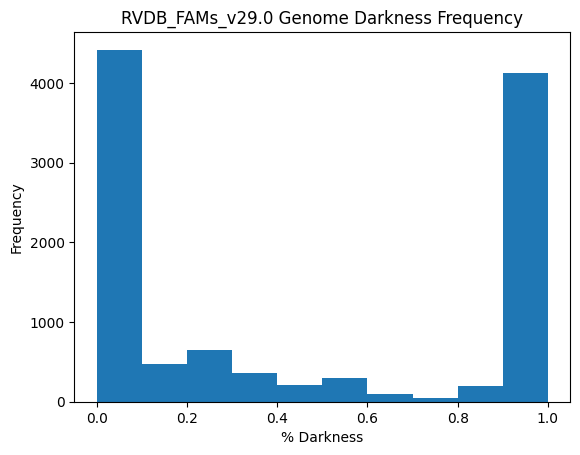

In [195]:
def plot_genome_darkness(genome_darkness_map, outfile):    
    plt.hist(list(genome_darkness_map.values()), bins=10, density=False)
    plt.xlabel("% Darkness")
    plt.ylabel("Frequency")
    plt.title(f"{db_name} Genome Darkness Frequency")
    plt.savefig(outfile)

outfile = os.path.join(outdir, "genome_darkness.png")
plot_genome_darkness(genome_darkness_map, outfile)

In [196]:
darkness_outfile = os.path.join(outdir, "genome_darkness.tsv")
with open(darkness_outfile, "w") as file:
    for genome, darkness in genome_darkness_map.items():
        file.write(f"{genome}\t{darkness}\n")

In [197]:
# write_fam_sequences_to_faa(outdir, seq_map, tax_map)
#
def write_fam_sequences_to_faa(outdir, seq_map, tax_map):
    for fam, genome_map in seq_map.items():
        with open(os.path.join(outdir, f"{fam}-sliced.faa"), "w") as file:
            for genome, prot_map in genome_map.items():
                for prot, seqs in prot_map.items():
                    for seq in seqs:
                        file.write(f">{genome}:{prot}:{tax_map[genome]}\n")
                        file.write(f"{seq}\n")
                    
# write fam sequences
fastas_outdir = os.path.join(outdir, "sequences")
make_dir(fastas_outdir)
# write_fam_sequences_to_faa(fastas_outdir, fam_seq_map, tax_map)

In [ ]:
# tax -> genomes
tax_genomes_map = defaultdict(list)
for genome, tax in tax_map.items():
    tax_genomes_map[tax].append(genome)
tax_genomes_map = dict(sorted(tax_genomes_map.items()))

In [199]:
# only keep highest fam for each prot
for genome, prot_map in prot_bitscores.items():
    for prot, fam_map in prot_map.items():
        best_fam = None
        highest_bitscore = -math.inf
        for fam, scores in fam_map.items():
            avg_score = sum(scores) / len(scores)
            if avg_score > highest_bitscore:
                best_fam = fam
                highest_bitscore = avg_score
        
        for fam in list(prot_fam_coords[genome][prot].keys()):
            if fam != best_fam:
                prot_fam_coords[genome][prot].pop(fam)

In [200]:
hits_outfile = os.path.join(outdir, "hits.tsv")
with open(hits_outfile, "w") as file:
    file.write("QUERY\tFAM\tLINEAGE\n")
    for genome, prot_fam_map in prot_fam_coords.items():
        for prot, fam_coords_map in prot_fam_map.items():
            for fam in fam_coords_map.keys():
                file.write(f"{genome}_{prot}\t{fam}\t{tax_map[genome]}\n")

In [201]:
# get_taxa_level_groups
#
def get_taxa_level_groups(tax_map):
    temp_tax_map = {genome: tax.split("; ") for genome, tax in tax_map.items()}

    all_taxa_level_groups = defaultdict(list)

    for genome, taxa_list in temp_tax_map.items():
        for level in range(1, len(taxa_list)):
            all_taxa_level_groups["; ".join(taxa_list[:level])].append(genome)

    return dict(sorted(all_taxa_level_groups.items(), reverse=True))


all_taxa_level_groups = get_taxa_level_groups(tax_map)

In [205]:
def get_overlap(a, b):
    return max(0, min(a[1], b[1]) - max(a[0], b[0]))


def move_fam_position(fam_position, gap):
    if fam_position[0] <= gap[0]:
        return [(fam_position[0], gap[0]), (gap[1], gap[1] + (fam_position[1] - gap[0]))]
    else:
        return [(fam_position[0] + (gap[1] - gap[0]), fam_position[1] + (gap[1] - gap[0]))]

# get_fam_architecture(prot_fam_coords, gene_pos_map
#
def get_fam_architecture(prot_fam_coords, gene_pos_map):
    new_prot_fam_coords = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

    for genome, pos_map in gene_pos_map.items():
        for gene, gene_positions in pos_map.items():
            # get the smallest value
            gene_left_end = math.inf
            for coords in gene_positions:
                if coords[0] < gene_left_end:
                    gene_left_end = coords[0]
                if coords[1] < gene_left_end:
                    gene_left_end = coords[1]

            gaps = list()
            order_gene_positions = sorted([(min(start, stop), max(start, stop)) for start, stop in gene_positions])
            if len(order_gene_positions) > 1:
                gap = (order_gene_positions[0][1], )
                for coords in order_gene_positions[1:]:
                    gap += (coords[0], )
                    gaps.append(gap)
                    gap = (coords[1], )

            for fam, all_fam_coords in prot_fam_coords[genome][gene].items():

                for fam_coords in all_fam_coords:
                    # if prot_bitscores[genome][gene][fam] > fam_lowest_thresh_map[fam]:

                    fam_start = gene_left_end + (fam_coords[0] * 3)
                    fam_stop = gene_left_end + (fam_coords[1] * 3)

                    fam_positions = [(fam_start, fam_stop)]

                    # check if it overlaps a gap
                    for gap in gaps:
                        for fam_position in fam_positions:
                            if get_overlap(fam_position, gap) > 0:    
                                fam_positions.remove(fam_position)
                                fam_positions += move_fam_position(fam_position, gap)
                                break
                    
                    for fam_position in fam_positions:
                        new_prot_fam_coords[genome][gene][fam].append(fam_position)

    return new_prot_fam_coords

# write_genome_fam_architecture(outdir, all_taxa_level_groups, new_prot_fam_coords)
#
def write_genome_fam_architecture(outdir, all_taxa_level_groups, new_prot_fam_coords):
    seen_genomes = set()
    with open(os.path.join(outdir, f"fams.tsv"), "w") as file:
        for tax, genomes in all_taxa_level_groups.items():
            for genome in genomes:
                if genome not in seen_genomes:
                    for gene, fam_map in new_prot_fam_coords[genome].items():
                        for fam, positions in fam_map.items():
                            file.write(f"{tax}\t{genome}\t{gene}\t{fam}")
                            for position in positions:
                                file.write(f"\t{position}")
                            file.write(f"\n")

                    seen_genomes.add(genome)
            
# genome -> protein -> fam: [(start1, end1), ...]
new_prot_fam_coords = get_fam_architecture(prot_fam_coords, gene_pos_map)
write_genome_fam_architecture(outdir, all_taxa_level_groups, new_prot_fam_coords)

In [206]:
# get_genome_magnitudes(gene_pos_map)
#
def get_genome_magnitudes(gene_pos_map):
    genome_stucture_map = defaultdict(list)

    # get magnitudes
    for genome, pos_map in gene_pos_map.items():
        for i, (gene, gene_positions) in enumerate(pos_map.items()):
            genome_stucture_map[genome].append(list())
            for coords in gene_positions:
                genome_stucture_map[genome][i].append(coords[1] - coords[0])
    
    return genome_stucture_map


# write_genome_magnitudes(outdir, all_taxa_level_groups, genome_stucture_map)
#
def write_genome_magnitudes(outdir, all_taxa_level_groups, genome_stucture_map):
    seen_genomes = set()
    with open(os.path.join(outdir, f"maginitudes.tsv"), "w") as file:
        for tax, genomes in all_taxa_level_groups.items():
            for genome in genomes:
                if genome not in seen_genomes:
                    file.write(f"{tax}\t{genome}")
                    for magnitude in genome_stucture_map[genome]:
                        file.write(f"\t{magnitude}")
                    file.write(f"\n")

                    seen_genomes.add(genome)


# get_taxanomic_level_structural_similarity(genome_stucture_map, all_taxa_level_groups)
#
def get_taxanomic_level_structural_similarity(genome_stucture_map, all_taxa_level_groups):
    norm_tax_similarity_map = dict()
    raw_tax_similarity_map = dict()

    # pad arrays
    max_len = max([len(sub_array) for genome in genome_stucture_map.keys() for sub_array in genome_stucture_map[genome]])
    max_width = max([len(genome_stucture_map[genome]) for genome in genome_stucture_map.keys()])
    for genome in genome_stucture_map.keys():
        for sub_array in genome_stucture_map[genome]:
            while len(sub_array) < max_len:
                sub_array.append(0)

    for tax, genomes in all_taxa_level_groups.items():
        distances = list()
        if len(genomes) < 1000:
            for ref_genome in genomes:
                reference = np.array(genome_stucture_map[ref_genome])
                distances += [dtw(reference, np.array(genome_stucture_map[other_genome])) for other_genome in genomes]

        else:
            for i in range(50):
                ref_genome = random.choice(genomes)
                reference = np.array(genome_stucture_map[ref_genome])
                distances += [dtw(reference, np.array(genome_stucture_map[other_genome])) for other_genome in genomes]
        
        distance = sum(distances) / len(distances)

        '''
        for genome in genomes:
            print(genome_stucture_map[genome])
            
            for gene, gene_positions in gene_pos_map[genome].items():
                print(f"\n{gene}: ", end="")

                for fam, all_fam_coords in prot_fam_coords[genome][gene].items():
                    print(f"\n{fam}: ", end="")
                    for fam_coords in all_fam_coords:
                        print(f"{fam_coords}, ", end="")
        '''

        raw_tax_similarity_map[tax] = distance
        print(f"{tax}: {distance}")
    
    # normalize
    max_dist = max(raw_tax_similarity_map.values())
    min_dist = min(raw_tax_similarity_map.values())
    for tax, distance in raw_tax_similarity_map.items():
        norm_tax_similarity_map[tax] = (distance - min_dist) / (max_dist - min_dist)

    return norm_tax_similarity_map, raw_tax_similarity_map

genome_stucture_map = get_genome_magnitudes(gene_pos_map)
write_genome_magnitudes(outdir, all_taxa_level_groups, genome_stucture_map)
norm_tax_structure_similarity_map, raw_tax_structure_similarity_map = get_taxanomic_level_structural_similarity(genome_stucture_map, all_taxa_level_groups)

Viruses; environmental samples: 0.0
Viruses; Varidnaviria; Helvetiavirae; Dividoviricota; Laserviricetes; Halopanivirales; Sphaerolipoviridae; Alphasphaerolipovirus; Alphasphaerolipovirus viikkii: 0.0
Viruses; Varidnaviria; Helvetiavirae; Dividoviricota; Laserviricetes; Halopanivirales; Sphaerolipoviridae; Alphasphaerolipovirus; Alphasphaerolipovirus serpentinense: 0.0
Viruses; Varidnaviria; Helvetiavirae; Dividoviricota; Laserviricetes; Halopanivirales; Sphaerolipoviridae; Alphasphaerolipovirus; Alphasphaerolipovirus pinkense: 0.0
Viruses; Varidnaviria; Helvetiavirae; Dividoviricota; Laserviricetes; Halopanivirales; Sphaerolipoviridae; Alphasphaerolipovirus; Alphasphaerolipovirus helsinkii: 0.0
Viruses; Varidnaviria; Helvetiavirae; Dividoviricota; Laserviricetes; Halopanivirales; Sphaerolipoviridae; Alphasphaerolipovirus: 1648.8806637887878
Viruses; Varidnaviria; Helvetiavirae; Dividoviricota; Laserviricetes; Halopanivirales; Sphaerolipoviridae: 1648.8806637887878
Viruses; Varidnaviri

In [ ]:
def jaccard_distance(set1, set2):
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return 1 - intersection / union if union > 0 else 0

# get_taxanomic_level_fam_similarity(new_prot_fam_coords, all_taxa_level_groups)
#
def get_taxanomic_level_fam_similarity(new_prot_fam_coords, all_taxa_level_groups):
    tax_similarity_map = dict()

    genome_fam_map = defaultdict(set)
    for genome, prot_fam_map in new_prot_fam_coords.items():
        for gene, fam_map in prot_fam_map.items():
            for fam in fam_map.keys():
                genome_fam_map[genome].add(fam)

    for tax, genomes in all_taxa_level_groups.items():
        distances = list()
        for ref_genome in genomes:
            distances += [jaccard_distance(genome_fam_map[ref_genome], genome_fam_map[other_genome]) for other_genome in genomes]

        distance = sum(distances) / len(distances)
        
        tax_similarity_map[tax] = distance
        print(f"{tax}: {distance}")

    return tax_similarity_map
    
tax_fam_similarity_map = get_taxanomic_level_fam_similarity(new_prot_fam_coords, all_taxa_level_groups)

Viruses; environmental samples: 0.0
Viruses; Varidnaviria; Helvetiavirae; Dividoviricota; Laserviricetes; Halopanivirales; Sphaerolipoviridae; Alphasphaerolipovirus; Alphasphaerolipovirus viikkii: 0.0
Viruses; Varidnaviria; Helvetiavirae; Dividoviricota; Laserviricetes; Halopanivirales; Sphaerolipoviridae; Alphasphaerolipovirus; Alphasphaerolipovirus serpentinense: 0.0
Viruses; Varidnaviria; Helvetiavirae; Dividoviricota; Laserviricetes; Halopanivirales; Sphaerolipoviridae; Alphasphaerolipovirus; Alphasphaerolipovirus pinkense: 0.0
Viruses; Varidnaviria; Helvetiavirae; Dividoviricota; Laserviricetes; Halopanivirales; Sphaerolipoviridae; Alphasphaerolipovirus; Alphasphaerolipovirus helsinkii: 0.0
Viruses; Varidnaviria; Helvetiavirae; Dividoviricota; Laserviricetes; Halopanivirales; Sphaerolipoviridae; Alphasphaerolipovirus: 0.1875
Viruses; Varidnaviria; Helvetiavirae; Dividoviricota; Laserviricetes; Halopanivirales; Sphaerolipoviridae: 0.1875
Viruses; Varidnaviria; Helvetiavirae; Divido

In [ ]:
def write_dict_to_file(outfile, map):
    with open(outfile, "w") as file:
        for key, val in map.items():
            file.write(f"{key}\t{val}\n")

outfile = os.path.join(outdir, "raw_taxonomic_level_structure_similarity.tsv")
write_dict_to_file(outfile, raw_tax_structure_similarity_map)

outfile = os.path.join(outdir, "normalized_taxonomic_level_structure_similarity.tsv")
write_dict_to_file(outfile, norm_tax_structure_similarity_map)

outfile = os.path.join(outdir, "taxonomic_level_fam_similarity.tsv")
write_dict_to_file(outfile, tax_fam_similarity_map)

In [ ]:
RANK_SUFFIX_MAP = {
    "Domain": ["Viruses"],
    "Realm": ["viria"],
    "Kingdom": ["virae"],
    "Phylum": ["viricota"],
    "Subphylum": ["viricotina"],
    "Class": ["viricetes"],
    "Order": ["virales"],
    "Suborder": ["virineae"],
    "Family": ["viridae", "formidae", "satellitidae"],
    "Subfamily": ["virinae", "satellitinae"],
    "Genus": ["virus", "form", "satellite"]
}
# note: Species can be identified by having a space

ORDERED_TAXA_RANKS = ["Domain", "Realm", "Kingdom", "Phylum", "Subphylum", "Class", "Order", "Suborder", "Family", "Subfamily", "Genus", "Species"]


def identify_rank(taxonomy_name):
    if " " in taxonomy_name:
        return "Species"
    for rank, suffixes in RANK_SUFFIX_MAP.items():
        for suffix in suffixes:
            if taxonomy_name.endswith(suffix):
                return rank
    return None


def plot_level_similarity(tax_structure_similarity_map, tax_fam_similarity_map, outfile):
    level_structure_similarity_map = defaultdict(list)
    level_fam_similarity_map = defaultdict(list)

    for tax in tax_structure_similarity_map.keys():
        struct_distance = tax_structure_similarity_map[tax]
        fam_distance = tax_fam_similarity_map[tax]

        rank = identify_rank(tax.split("; ")[-1])
        level_structure_similarity_map[rank].append(struct_distance)
        level_fam_similarity_map[rank].append(fam_distance)

    avg_level_structure_similarity = list()
    avg_level_fam_similarity = list()
    for label in ORDERED_TAXA_RANKS:
        if label in level_structure_similarity_map.keys():
            avg_level_structure_similarity.append( 1 - (sum(level_structure_similarity_map[label]) / len(level_structure_similarity_map[label])) )
        else:
            avg_level_structure_similarity.append(0)

        if label in level_fam_similarity_map.keys():
            avg_level_fam_similarity.append( 1 - (sum(level_fam_similarity_map[label]) / len(level_fam_similarity_map[label])) )
        else:
            avg_level_fam_similarity.append(0)

    x = np.arange(len(ORDERED_TAXA_RANKS))
    width = 0.35 
    fig, ax = plt.subplots(figsize=(20,15))
    rects1 = ax.bar(x - width/2, avg_level_structure_similarity, width, label='structural similarity')
    rects2 = ax.bar(x + width/2, avg_level_fam_similarity, width, label='fam composition similarity')
    ax.set_ylabel('%')
    ax.set_title('Level Similarity')
    ax.set_xticks(x)
    ax.set_xticklabels(ORDERED_TAXA_RANKS)
    ax.legend()

    plt.savefig(outfile)

outfile = os.path.join(outdir, "level_similarity.png")
plot_level_similarity(norm_tax_structure_similarity_map, tax_fam_similarity_map, outfile)

In [ ]:
# write_architecture_to_file(outdir, prot_fam_coords, gene_pos_map, full_genome_region, all_taxa_level_groups)
#
def write_architecture_to_file(outdir, prot_fam_coords, gene_pos_map, full_genome_region, all_taxa_level_groups):
    for tax, genomes in all_taxa_level_groups.items():
        # if tax == "Viruses; Riboviria; Orthornavirae; Pisuviricota; Stelpaviricetes":
        plt.figure(figsize=(15, 10))
        plt.title(f"{tax}")

        # texts = list()
        
        pos = 0

        for genome in genomes:
            pos += 10

            plt.plot([full_genome_region[genome][0], full_genome_region[genome][1]], [pos, pos], color='black')

            plt.text(full_genome_region[genome][1] + 50, pos, genome, fontsize=12, color='black', ha='center')

            width = full_genome_region[genome][1] - full_genome_region[genome][0]
            height = 0
            for gene, gene_positions in gene_pos_map[genome].items():
                height += 10 * ((len(prot_fam_coords[genome][gene]))+1)

            for gene, gene_positions in gene_pos_map[genome].items():
                pos += 10

                for coords in gene_positions:
                    gene_section_start = coords[0]
                    gene_section_stop = coords[1]
                    plt.arrow(
                        gene_section_start, 
                        pos, 
                        gene_section_stop - gene_section_start, 
                        0, 
                        head_width=height * 0.01, 
                        head_length=width * 0.01,
                        length_includes_head = True, 
                        color='red'
                    )
                    
                # plt.text(gene_section_stop + 50, pos, gene, fontsize=12, color='black', ha='center')

                for fam, all_fam_coords in prot_fam_coords[genome][gene].items():
                    pos += 10

                    for fam_coords in all_fam_coords:
                        plt.arrow(
                            fam_coords[0], 
                            pos, fam_coords[1] - fam_coords[0], 
                            0, 
                            # head_width=height * 0.005, 
                            # head_length=width * 0.005, 
                            length_includes_head = True, 
                            color='blue'
                        )

                    # texts.append(plt.text(fam_coords[1], pos, fam, fontsize=10, color='black', ha='left'))
        
        # adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black'))
        # plt.savefig(os.path.join(outdir, f"{genome}_architecture.png"))
        plt.show()

        plt.close()

# write genome architecture to files
architecture_outdir = os.path.join(outdir, "architecture")
make_dir(architecture_outdir)
# write_architecture_to_file(architecture_outdir, new_prot_fam_coords, gene_pos_map, full_genome_region, all_taxa_level_groups)